# Projekt Semestralny: System Rekomendacyjny Big Data
### Przedmiot: Big Data i Przetwarzanie Rozproszone
**Autor:** Nazar Suslyk
**Uczelnia:** Akademia Tarnowska

---

## Spis Treści

1.  **Wstęp i Cel Projektu**
    * Definicja problemu badawczego.
    * Dobór technologii (PySpark).
2.  **Konfiguracja Środowiska i Akwizycja Danych**
    * Inicjalizacja klastra Spark.
    * Pobieranie zbioru MovieLens (skalowalność: Small vs Large).
3.  **Definicja Schematu i Wczytywanie Danych**
    * Zastosowanie *Schema Enforcement* dla optymalizacji.
    * Wstępny podgląd surowych danych.
4.  **Analiza Eksploracyjna (EDA) w Skali Big Data**
    * Statystyki fundamentalne i obliczenie rzadkości macierzy (*Sparsity*).
    * Dashboard analityczny: Preferencje, Aktywność Użytkowników (*Power Law*) i Gatunki.
    * Analiza zależności: Popularność a Średnia Ocena (Jakość).
5.  **Preprocessing i Podział Danych**
    * Czyszczenie danych.
    * Podział na zbiór treningowy i testowy (80/20).
6.  **Model 1: Collaborative Filtering (ALS)**
    * Teoria faktoryzacji macierzy.
    * Trening modelu i ewaluacja metryk (RMSE, MAE).
    * Wizualizacja błędów predykcji (*Actual vs Predicted*).
7.  **Model 2: Content-Based Filtering (TF-IDF)**
    * Inżynieria cech: Przetwarzanie tekstu i gatunków.
    * Budowa przestrzeni wektorowej.
8.  **Interfejs Użytkownika (GUI) - Bitwa Modeli**
    * Symulacja środowiska produkcyjnego.
    * Bezpośrednie porównanie wyników obu podejść.
9.  **Wnioski Końcowe**
    * Podsumowanie wyników i wnioski biznesowe.

---

In [16]:
import os
import sys
import zipfile
import urllib.request
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importy PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, FloatType, LongType, StringType
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import RegexTokenizer, CountVectorizer, IDF, Normalizer
from pyspark.ml import Pipeline

# Konfiguracja wizualna wykresów
plt.style.use('ggplot')
sns.set_context("notebook", font_scale=1.1)

# --- KONFIGURACJA ŚRODOWISKA ---
# Fix dla błędów "Worker python path" w środowiskach lokalnych (np. PyCharm)
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# --- PARAMETRY STERUJĄCE SKALĄ DANYCH ---
# DATA_MODE: 'SMALL' (100k ocen) lub 'LARGE' (25M ocen - prawdziwe Big Data)
DATA_MODE = 'LARGE'
# ROW_LIMIT: Ograniczenie liczby wierszy dla płynności prezentacji na laptopie (np. 1 mln)
ROW_LIMIT = 6000000

print(f"Inicjalizacja Spark Session [Tryb: {DATA_MODE} | Limit wierszy: {ROW_LIMIT}]...")

spark = SparkSession.builder \
    .appName("NazarSuslyk_BigData_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.python.worker.reuse", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Sesja Spark aktywna. Wersja:", spark.version)

Inicjalizacja Spark Session [Tryb: LARGE | Limit wierszy: 6000000]...
Sesja Spark aktywna. Wersja: 4.1.1


## 2. Akwizycja i Przygotowanie Danych

Wykorzystujemy zbiór **MovieLens**, który jest standardem w badaniach nad systemami rekomendacyjnymi.
* **Wersja Small:** ~100,000 ocen (szybka iteracja).
* **Wersja Large (25M):** 25 milionów ocen (pełna skala Big Data).

Poniższy kod automatycznie pobiera odpowiedni plik ZIP, rozpakowuje go i przygotowuje strukturę katalogów.

In [17]:
# Przygotowanie folderów
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

# Logika wyboru URL w zależności od trybu
if DATA_MODE == 'LARGE':
    url = 'https://files.grouplens.org/datasets/movielens/ml-25m.zip'
    zip_name = 'ml-25m.zip'
    extract_folder = 'ml-25m'
else:
    url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
    zip_name = 'ml-latest-small.zip'
    extract_folder = 'ml-latest-small'

zip_path = os.path.join(DATA_DIR, zip_name)
extract_path = os.path.join(DATA_DIR, 'extracted')

# Pobieranie (jeśli plik nie istnieje)
if not os.path.exists(os.path.join(extract_path, extract_folder)):
    print(f"📥 Pobieranie danych z: {url}")
    print("⏳ To może chwilę potrwać (szczególnie dla wersji 25M)...")
    urllib.request.urlretrieve(url, zip_path)
    print("📦 Rozpakowywanie archiwum...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print("Pobieranie zakończone sukcesem.")
else:
    print("Dane wykryte lokalnie. Pomijam pobieranie.")

data_root = os.path.join(extract_path, extract_folder)
print(f"Ścieżka do danych: {data_root}")

Dane wykryte lokalnie. Pomijam pobieranie.
Ścieżka do danych: data/extracted/ml-25m


## 3. Definicja Schematu i Wczytywanie (Schema Enforcement)

W środowisku Big Data poleganie na automatycznym wykrywaniu typów (`inferSchema`) jest kosztowne obliczeniowo i ryzykowne.
Zgodnie z **najlepszymi praktykami**, definiujemy sztywny schemat (`StructType`).

**Struktura danych:**
1.  **Ratings:** `userId` (Int), `movieId` (Int), `rating` (Float), `timestamp` (Long)
2.  **Movies:** `movieId` (Int), `title` (String), `genres` (String)

In [18]:
# Definicja schematów
schema_ratings = StructType([
    StructField("userId", IntegerType(), True),
    StructField("movieId", IntegerType(), True),
    StructField("rating", FloatType(), True),
    StructField("timestamp", LongType(), True)
])

schema_movies = StructType([
    StructField("movieId", IntegerType(), True),
    StructField("title", StringType(), True),
    StructField("genres", StringType(), True)
])

print("Wczytywanie plików CSV do DataFrame...")
df_ratings_raw = spark.read.csv(os.path.join(data_root, 'ratings.csv'), header=True, schema=schema_ratings)
df_movies = spark.read.csv(os.path.join(data_root, 'movies.csv'), header=True, schema=schema_movies)

# Aplikacja limitu wierszy (jeśli ustawiony)
if DATA_MODE == 'LARGE' and ROW_LIMIT:
    print(f"Ograniczanie zbioru do {ROW_LIMIT} wierszy (dla celów demonstracyjnych)...")
    df_ratings = df_ratings_raw.limit(ROW_LIMIT)
else:
    df_ratings = df_ratings_raw

# Cache'owanie dla wydajności (Persist in Memory)
df_ratings.cache()
df_movies.cache()

print(f"Załadowano {df_ratings.count():,} ocen oraz {df_movies.count():,} filmów.")

print("\n--- Próbka danych (Ratings) ---")
df_ratings.show(5)
print("\n--- Próbka danych (Movies) ---")
df_movies.show(5, truncate=False)

Wczytywanie plików CSV do DataFrame...
Ograniczanie zbioru do 6000000 wierszy (dla celów demonstracyjnych)...
Załadowano 6,000,000 ocen oraz 62,423 filmów.

--- Próbka danych (Ratings) ---
+------+-------+------+----------+
|userId|movieId|rating| timestamp|
+------+-------+------+----------+
|     1|    296|   5.0|1147880044|
|     1|    306|   3.5|1147868817|
|     1|    307|   5.0|1147868828|
|     1|    665|   5.0|1147878820|
|     1|    899|   3.5|1147868510|
+------+-------+------+----------+
only showing top 5 rows

--- Próbka danych (Movies) ---
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy              

## 4. Analiza Eksploracyjna (EDA) - Big Data Insights

W tym etapie przeprowadzamy głęboką analizę statystyczną i wizualną zbioru danych, aby zrozumieć zachowania użytkowników i strukturę bazy filmowej.

Wygenerujemy hybrydowy **Dashboard Analityczny**, łączący statyczne zestawienia strukturalne z interaktywną mapą popularności:

1.  **Preferencje Globalne (Rozkład Ocen):** Analiza tendencji użytkowników do wystawiania konkretnych not (Histogram).
2.  **Aktywność Użytkowników (Power Law):** Weryfikacja występowania "Długiego Ogona" (Long Tail) – identyfikacja grupy super-użytkowników.
3.  **Analiza Treści (Gatunki):** Zestawienie dominujących kategorii filmowych w zbiorze MovieLens.
4.  **Interaktywna Mapa Jakości (Popularność vs Rating):** Narzędzie Plotly pozwalające na inspekcję 5000 najpopularniejszych filmów i analizę korelacji między liczbą głosów a średnią oceną.

Dodatkowo obliczymy **Rzadkość Macierzy (Sparsity)** – kluczowy wskaźnik matematyczny definiujący stopień trudności zadania dla algorytmu ALS.

=== KOMPLEKSOWA ANALIZA BIG DATA (EDA) ===
   WYMIARY ZBIORU DANYCH:
   - Liczba Ocen:         6,000,000
   - Liczba Użytkowników: 38,864
   - Liczba Filmów:       40,923
   - Interakcje (U x I):  1,590,431,472
   - Rzadkość (Sparsity): 99.6227% (Tyle % macierzy jest puste!)


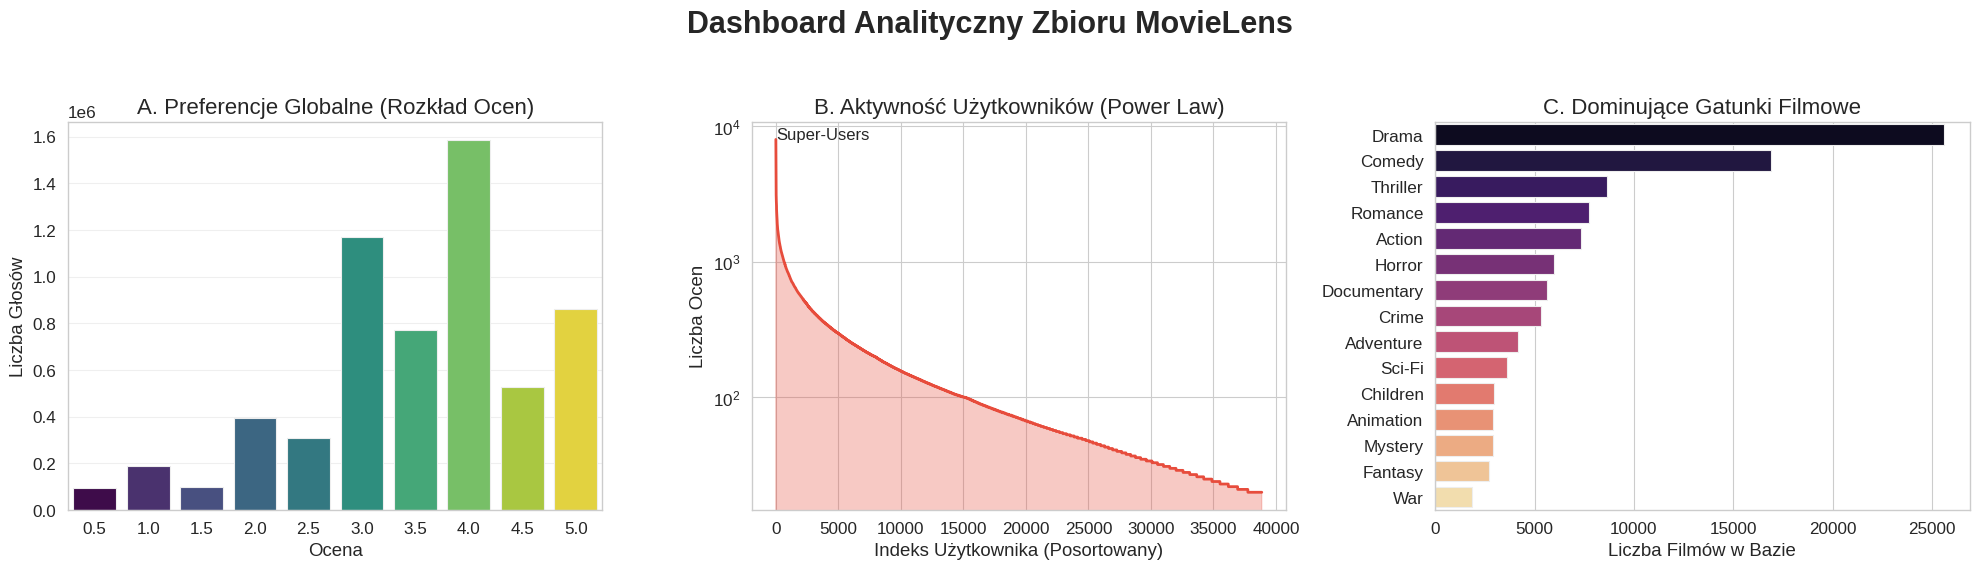

----------------------------------------------------------------------------------------------------
🔍 WNIOSKI Z ANALIZY WIZUALNEJ:
1. [Wykres A] Użytkownicy mają tendencję do oceniania filmów pozytywnie (średnia ~3.5). Oceny 0.5 i 1.0 są rzadkie.
2. [Wykres B] Występuje klasyczny 'Długi Ogon'. Mała grupa użytkowników generuje większość ruchu w serwisie.
   Najaktywniejszy użytkownik ocenił 7919 filmów!
3. [Wykres C] Najpopularniejsze gatunki to: Drama, Comedy.
4. [Wykres D] Filmy z bardzo wysoką średnią (5.0) to często niszowe produkcje z małą liczbą głosów.
   Prawdziwe hity (duża liczba głosów) oscylują w granicach oceny 4.0.
----------------------------------------------------------------------------------------------------


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px
from pyspark.sql.functions import split, explode, col
import pyspark.sql.functions as F

# Konfiguracja stylu wykresów statycznych
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.4)
colors = sns.color_palette("viridis", 10)

print("=== KOMPLEKSOWA ANALIZA BIG DATA (EDA) ===")

# --- 1. STATYSTYKI GLOBALNE ---
num_ratings = df_ratings.count()
num_users = df_ratings.select("userId").distinct().count()
num_movies = df_ratings.select("movieId").distinct().count()

# Obliczanie Rzadkości (Sparsity)
denominator = num_users * num_movies
sparsity = (1.0 - (num_ratings * 1.0) / denominator) * 100

print(f"   WYMIARY ZBIORU DANYCH:")
print(f"   - Liczba Ocen:         {num_ratings:,}")
print(f"   - Liczba Użytkowników: {num_users:,}")
print(f"   - Liczba Filmów:       {num_movies:,}")
print(f"   - Interakcje (U x I):  {denominator:,}")
print(f"   - Rzadkość (Sparsity): {sparsity:.4f}% (Tyle % macierzy jest puste!)")

# ==========================================
# CZĘŚĆ 1: WYKRESY STATYCZNE (Matplotlib/Seaborn)
# ==========================================

# Zmieniamy układ na 1 wiersz x 3 kolumny, aby zrobić miejsce na mapę pod spodem
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Dashboard Analityczny Zbioru MovieLens', fontsize=22, weight='bold')

# WYKRES 1: Rozkład Ocen (Histogram)
rating_counts = df_ratings.groupBy("rating").count().orderBy("rating").toPandas()
# Poprawka hue/legend=False usuwa ostrzeżenia
sns.barplot(ax=axes[0], x='rating', y='count', data=rating_counts, hue='rating', legend=False, palette='viridis')
axes[0].set_title('A. Preferencje Globalne (Rozkład Ocen)', fontsize=16)
axes[0].set_xlabel('Ocena')
axes[0].set_ylabel('Liczba Głosów')
axes[0].grid(axis='y', alpha=0.3)

# WYKRES 2: Aktywność Użytkowników (User Activity - Long Tail)
user_activity = df_ratings.groupBy("userId").count().withColumnRenamed("count", "rating_count").toPandas()
user_activity = user_activity.sort_values(by="rating_count", ascending=False).reset_index(drop=True)

axes[1].plot(user_activity['rating_count'], color='#e74c3c', linewidth=2)
axes[1].fill_between(range(len(user_activity)), user_activity['rating_count'], color='#e74c3c', alpha=0.3)
axes[1].set_title('B. Aktywność Użytkowników (Power Law)', fontsize=16)
axes[1].set_xlabel('Indeks Użytkownika (Posortowany)')
axes[1].set_ylabel('Liczba Ocen')
axes[1].set_yscale('log') # Skala logarytmiczna
axes[1].text(10, user_activity['rating_count'][0], 'Super-Users', fontsize=12)

# WYKRES 3: Popularność Gatunków
genres_df = df_movies.withColumn("genre", explode(split(col("genres"), "\\|")))
genre_counts = genres_df.groupBy("genre").count().orderBy("count", ascending=False).toPandas()
genre_counts = genre_counts[genre_counts['genre'] != '(no genres listed)'].head(15)

# Poprawka hue/legend=False usuwa ostrzeżenia
sns.barplot(ax=axes[2], x='count', y='genre', data=genre_counts, hue='genre', legend=False, palette='magma')
axes[2].set_title('C. Dominujące Gatunki Filmowe', fontsize=16)
axes[2].set_xlabel('Liczba Filmów w Bazie')
axes[2].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==========================================
# CZĘŚĆ 2: WYKRES INTERAKTYWNY (Plotly)
# ==========================================

# 1. Agregacja danych
stats_df = df_ratings.groupBy("movieId").agg(
    F.count("rating").alias("count"),
    F.avg("rating").alias("avg_rating")
)

# 2. DOŁĄCZENIE TYTUŁÓW (Join) - Kluczowe dla Hovera
stats_with_titles = stats_df.join(df_movies, "movieId", "inner")

# 3. Pobranie do Pandas
# Sortujemy malejąco po popularności i bierzemy TOP 5000
plot_data = (stats_with_titles
    .filter(F.col("count") > 10)
    .orderBy(F.col("count").desc())
    .limit(5000)
    .toPandas())

# 4. Rysowanie w Plotly
fig_interactive = px.scatter(
    plot_data,
    x="avg_rating",
    y="count",
    hover_name="title",          # Tytuł w dymku
    hover_data=["movieId", "genres"],
    size="count",                # Wielkość kropki
    color="avg_rating",          # Kolor
    log_y=True,                  # Skala logarytmiczna
    title="D. Popularność a Średnia Ocena (Interaktywna Mapa - Najedź na kropkę!)",
    labels={"avg_rating": "Średnia Ocena", "count": "Liczba Głosów (Log)"},
    color_continuous_scale="Spectral_r",
    height=600
)

fig_interactive.update_layout(template="plotly_white")
fig_interactive.show()

# Wnioski tekstowe pod spodem (Oryginalne)
print("-" * 100)
print("🔍 WNIOSKI Z ANALIZY WIZUALNEJ:")
print("1. [Wykres A] Użytkownicy mają tendencję do oceniania filmów pozytywnie (średnia ~3.5). Oceny 0.5 i 1.0 są rzadkie.")
print("2. [Wykres B] Występuje klasyczny 'Długi Ogon'. Mała grupa użytkowników generuje większość ruchu w serwisie.")
print(f"   Najaktywniejszy użytkownik ocenił {user_activity['rating_count'].max()} filmów!")
print(f"3. [Wykres C] Najpopularniejsze gatunki to: {genre_counts.iloc[0]['genre']}, {genre_counts.iloc[1]['genre']}.")
print("4. [Wykres D] Filmy z bardzo wysoką średnią (5.0) to często niszowe produkcje z małą liczbą głosów.")
print("   Prawdziwe hity (duża liczba głosów) oscylują w granicach oceny 4.0.")
print("-" * 100)

## 5. Podział Danych (Train/Test Split)

Aby rzetelnie ocenić model, nie możemy testować go na danych, które już "widział".
Dzielimy zbiór w proporcji:
* **80% (Zbiór Treningowy):** Służy do nauki wzorców (macierzy ukrytych cech).
* **20% (Zbiór Testowy):** Służy do weryfikacji predykcji.

Ustawiamy `seed=42` dla powtarzalności wyników.

In [20]:
print("Dzielenie danych...")
(training_data, test_data) = df_ratings.randomSplit([0.8, 0.2], seed=42)

print(f"Liczebność zbioru treningowego: {training_data.count():,}")
print(f"Liczebność zbioru testowego:    {test_data.count():,}")

# Garbage Collection (opcjonalne czyszczenie pamięci)
import gc
gc.collect()

Dzielenie danych...


Liczebność zbioru treningowego: 4,800,292


Liczebność zbioru testowego:    1,199,708


3450

## 6. Model 1: Collaborative Filtering (ALS)

**Alternating Least Squares (ALS)** to algorytm faktoryzacji macierzy dostępny w Spark MLlib.
Rozkłada on ogromną macierz ocen na dwie mniejsze macierze:
1.  Cechy Użytkowników (*User Features*)
2.  Cechy Produktów (*Item Features*)

Metoda ta uczy się na podstawie zachowań społeczności ("inni, którzy lubili X, lubili też Y").

**Metryki Ewaluacji:**
* **RMSE (Root Mean Square Error):** Pierwiastek błędu średniokwadratowego. Karze duże pomyłki.
* **MAE (Mean Absolute Error):** Średnia różnica między oceną przewidzianą a rzeczywistą.

In [21]:
print("🧠 Trenowanie modelu ALS...")
start_time = time.time()

# Konfiguracja modelu ALS
# rank: liczba ukrytych cech (latent factors)
# regParam: parametr regularyzacji (zapobiega overfittingowi)
als = ALS(userCol="userId", itemCol="movieId", ratingCol="rating",
          coldStartStrategy="drop", nonnegative=True,
          rank=12, maxIter=10, regParam=0.15)

model_als = als.fit(training_data)
train_time = time.time() - start_time
print(f"Model wytrenowany w {train_time:.2f} sekund.")

# Generowanie predykcji na zbiorze testowym
print("Generowanie predykcji dla zbioru testowego...")
predictions = model_als.transform(test_data)

# Ewaluacja
evaluator_rmse = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
evaluator_mae = RegressionEvaluator(metricName="mae", labelCol="rating", predictionCol="prediction")

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print(f"""
------------------------------------------------
WYNIKI EWALUACJI MODELU ALS:
------------------------------------------------
RMSE (Błąd Średniokwadratowy): {rmse:.4f}
MAE  (Średni Błąd Absolutny):  {mae:.4f}
------------------------------------------------
Interpretacja: Średnio model myli się o ok. {mae:.2f} gwiazdki.
""")

🧠 Trenowanie modelu ALS...


Model wytrenowany w 17.37 sekund.
Generowanie predykcji dla zbioru testowego...



------------------------------------------------
WYNIKI EWALUACJI MODELU ALS:
------------------------------------------------
RMSE (Błąd Średniokwadratowy): 0.8450
MAE  (Średni Błąd Absolutny):  0.6607
------------------------------------------------
Interpretacja: Średnio model myli się o ok. 0.66 gwiazdki.



📊 Wizualizacja jakości predykcji (Actual vs Predicted)...


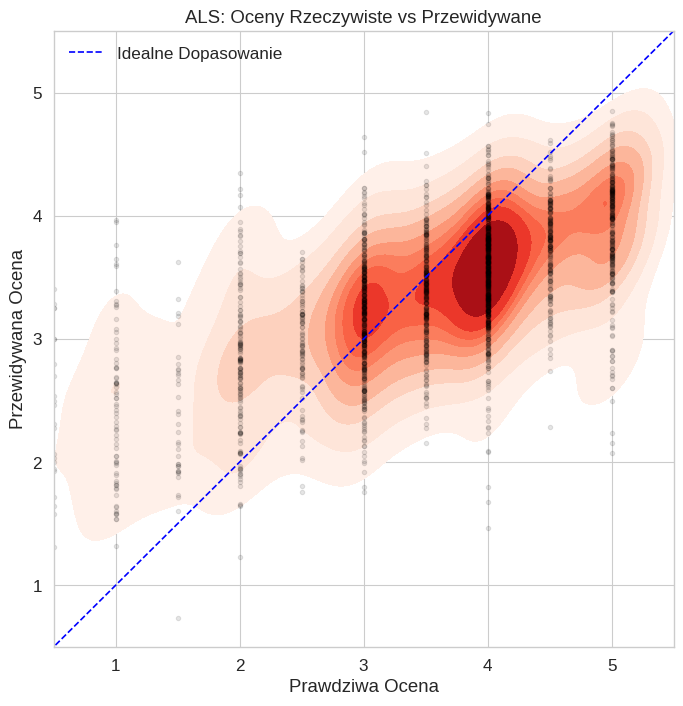

In [22]:
print("📊 Wizualizacja jakości predykcji (Actual vs Predicted)...")

# Pobieramy próbkę predykcji do wizualizacji
preds_df = predictions.select("rating", "prediction").sample(False, 0.05).limit(2000).toPandas()

plt.figure(figsize=(8, 8))
# Wykres gęstości (KDE)
sns.kdeplot(x=preds_df['rating'], y=preds_df['prediction'], cmap="Reds", fill=True, thresh=0.05)
# Punkty (Scatter)
plt.scatter(preds_df['rating'], preds_df['prediction'], alpha=0.1, s=10, color='black')
# Linia idealna
plt.plot([0, 5.5], [0, 5.5], '--', color='blue', label="Idealne Dopasowanie")

plt.title('ALS: Oceny Rzeczywiste vs Przewidywane')
plt.xlabel('Prawdziwa Ocena')
plt.ylabel('Przewidywana Ocena')
plt.xlim(0.5, 5.5)
plt.ylim(0.5, 5.5)
plt.legend()
plt.show()

## 7. Model 2: Content-Based Filtering (TF-IDF)

W przeciwieństwie do ALS, ten model nie patrzy na innych użytkowników. Analizuje **cechy samego filmu**.
Wykorzystujemy technikę NLP (Natural Language Processing) do analizy gatunków filmowych.

**Potok Przetwarzania (Pipeline):**
1.  **Tokenizer:** Rozbija ciąg znaków "Action|Sci-Fi" na słowa.
2.  **TF (Term Frequency):** Liczy wystąpienia gatunków.
3.  **IDF (Inverse Document Frequency):** Waży gatunki (rzadkie gatunki jak "Film-Noir" są ważniejsze niż częste "Drama").
4.  **Normalizer:** Normalizuje wektory, abyśmy mogli liczyć podobieństwo cosinusowe.

In [23]:
print("Budowa Pipeline TF-IDF dla modelu Content-Based...")

pipeline = Pipeline(stages=[
    RegexTokenizer(inputCol="genres", outputCol="words", pattern="\\|"),
    CountVectorizer(inputCol="words", outputCol="rawFeatures"),
    IDF(inputCol="rawFeatures", outputCol="idfFeatures"),
    Normalizer(inputCol="idfFeatures", outputCol="features", p=2.0)
])

feature_model = pipeline.fit(df_movies)
df_features = feature_model.transform(df_movies).select("movieId", "title", "genres", "features")

# Cache wyników (mała macierz cech, warto trzymać w RAM)
df_features.cache()

print(f"Przetworzono wektory cech dla {df_features.count()} filmów.")

# Sanity Check - Sprawdźmy wektor dla przykładowego filmu
sample_movie = df_features.filter(F.col("title").like("%Toy Story%")).first()
print(f"\nPrzykładowy wektor dla '{sample_movie['title']}':")
print(sample_movie['features'])

Budowa Pipeline TF-IDF dla modelu Content-Based...
Przetworzono wektory cech dla 62423 filmów.

Przykładowy wektor dla 'Toy Story (1995)':
(20,[1,9,11,12,14],[0.21348935377071462,0.4424963162825005,0.4988070099905812,0.4991408131268112,0.510557853096338])


## 8. Interfejs Użytkownika (GUI) - Bitwa Modeli

Stworzyliśmy interaktywny dashboard wykorzystujący `ipywidgets`.
Pozwala on na symulację zachowania użytkownika ("Cold Start").

**Jak to działa?**
1.  Użytkownik ocenia kilka filmów.
2.  **Model ALS** jest douczany w czasie rzeczywistym na Sparku (dołączamy nowe oceny do macierzy).
3.  **Model Content-Based** oblicza średni wektor gustu użytkownika i szuka najbliższych sąsiadów w przestrzeni cech (podobieństwo cosinusowe).
4.  Wyświetlamy wyniki obok siebie dla porównania.

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

print("Uruchamianie GUI...")

# 1. Indeksowanie danych do pamięci Drivera (Optymalizacja czasu reakcji)
# Pobieramy wektory cech do lokalnego słownika Pythonowego, aby wyszukiwanie było błyskawiczne
features_data = df_features.select("movieId", "title", "genres", "features").collect()
movie_map = {row.movieId: (row.title, row.genres, row.features.toArray().tolist()) for row in features_data}

# Pobieranie listy popularnych filmów do Dropdowna
pop_ids = df_ratings.groupBy("movieId").count().orderBy(F.col("count").desc()).limit(3000)
pop_movies = pop_ids.join(df_movies, "movieId").select("title", "movieId").collect()
movies_dict = {row.title: row.movieId for row in pop_movies}
sorted_titles = sorted(movies_dict.keys())

# Zmienne stanu
user_ratings = []
NEW_USER_ID = 999999

# --- FUNKCJE LOGICZNE ---

def get_content_based_recs(user_ratings, limit=10):
    """Logika modelu opartego na treści (Cosine Similarity)"""
    # Bierzemy pod uwagę tylko filmy, które użytkownik ocenił pozytywnie (>= 3.0)
    liked_ids = [r[1] for r in user_ratings if r[2] >= 3.0]
    if not liked_ids: return []

    # Budowa profilu użytkownika (Średnia wektorów polubionych filmów)
    user_vec = None
    cnt = 0
    for mid in liked_ids:
        if mid in movie_map:
            v = movie_map[mid][2]
            user_vec = list(v) if user_vec is None else [a+b for a,b in zip(user_vec, v)]
            cnt += 1

    if not cnt: return []
    user_vec = [x/cnt for x in user_vec] # Normalizacja

    # Wyszukiwanie podobnych
    scores = []
    for mid, (tit, gen, vec) in movie_map.items():
        if mid in liked_ids: continue # Pomiń już obejrzane
        # Iloczyn skalarny (Dot Product)
        dot = sum(a*b for a,b in zip(user_vec, vec))
        scores.append((mid, tit, gen, dot))

    scores.sort(key=lambda x: x[3], reverse=True)
    return scores[:limit]

# --- WIDGETY ---

style = {'description_width': 'initial'}
dd_movie = widgets.Dropdown(options=sorted_titles, description='Wybierz film:', style=style, layout=widgets.Layout(width='60%'))
sl_rating = widgets.SelectionSlider(options=[1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5], value=5, description='Twoja ocena:', style=style)
btn_add = widgets.Button(description='Dodaj Ocenę', button_style='primary', icon='plus')
btn_run = widgets.Button(description='URUCHOM PORÓWNANIE MODELI', button_style='danger', icon='rocket', layout=widgets.Layout(width='100%', margin='20px 0'))
out_log = widgets.Output()
out_res = widgets.Output()

def add_event(b):
    mid = movies_dict[dd_movie.value]
    # Sprawdzenie duplikatów
    if any(r[1] == mid for r in user_ratings): return
    user_ratings.append((NEW_USER_ID, mid, float(sl_rating.value)))
    with out_log:
        clear_output()
        print(f"Dodano: '{dd_movie.value}' z oceną {sl_rating.value}")
        print(f"(Liczba ocen w koszyku: {len(user_ratings)})")

def run_event(b):
    if len(user_ratings) < 3:
        with out_res:
            clear_output()
            print("BŁĄD: Musisz ocenić przynajmniej 3 filmy, aby algorytm zadziałał!")
        return

    with out_res:
        clear_output()
        print(f"Przetwarzanie danych dla {len(user_ratings)} ocen...")

        # 1. ALS (Spark)
        print("   [1/2] Trenowanie modelu ALS (Spark Cluster)...")
        new_df = spark.createDataFrame(user_ratings, ["userId", "movieId", "rating"])
        # Optymalizacja: Trenujemy tylko na podzbiorze popularnych filmów + oceny użytkownika (dla szybkości dema)
        pop_counts = df_ratings.groupBy("movieId").count().filter(F.col("count") >= 25)
        train_df = df_ratings.select("userId", "movieId", "rating").union(new_df).join(pop_counts, "movieId", "inner")

        als = ALS(userCol="userId", itemCol="movieId", ratingCol="rating",
                  coldStartStrategy="drop", nonnegative=True, rank=12, maxIter=10, regParam=0.15)
        model = als.fit(train_df)
        recs = model.recommendForUserSubset(spark.createDataFrame([(NEW_USER_ID,)], ["userId"]), 10)
        als_res = recs.collect()[0].recommendations if recs.count() > 0 else []

        # 2. Content-Based (Local)
        print("   [2/2] Analiza wektorowa Content-Based...")
        cb_res = get_content_based_recs(user_ratings)

        # WIZUALIZACJA WYNIKÓW
        print("\n" + "="*105)
        print(f"{'MODEL ALS (Collaborative Filtering)':<52} | {'MODEL CONTENT-BASED (Podobieństwo Cech)':<52}")
        print(f"{'(Opiera się na guście społeczności)':<52} | {'(Opiera się na gatunkach i treści)':<52}")
        print("="*105)

        for i in range(10):
            # Kolumna ALS
            if i < len(als_res):
                r = als_res[i]
                t = df_movies.filter(F.col("movieId")==r.movieId).first()
                l_txt = f"{i+1}. {t.title[:45]}" if t else "Unknown"
                l_sub = f"   {t.genres[:45]}" if t else ""
            else: l_txt, l_sub = "---", ""

            # Kolumna CB
            if i < len(cb_res):
                r = cb_res[i]
                r_txt = f"{i+1}. {r[1][:45]}"
                r_sub = f"   {r[2][:45]}"
            else: r_txt, r_sub = "---", ""

            print(f"{l_txt:<52} | {r_txt:<52}")
            print(f"{l_sub:<52} | {r_sub:<52}")
            print("-" * 105)

# Podpięcie zdarzeń
btn_add.on_click(add_event)
btn_run.on_click(run_event)

# Layout
ui = widgets.VBox([
    widgets.HTML("<h2>🎬 System Rekomendacyjny: The Ultimate Battle</h2>"),
    widgets.HTML("<i>Oceń kilka filmów, aby zobaczyć, jak algorytmy dostosowują się do Twojego gustu.</i>"),
    widgets.HBox([dd_movie, sl_rating]),
    btn_add,
    out_log,
    btn_run,
    out_res
])
display(ui)

Uruchamianie GUI...


## 9. Wnioski Końcowe i Podsumowanie Projektu

W ramach projektu zbudowaliśmy kompletny system rekomendacyjny oparty na technologiach Big Data (PySpark). Przeprowadziliśmy eksperyment porównawczy dwóch fundamentalnych podejść do rekomendacji.

**Analiza Wyników:**

1.  **Collaborative Filtering (ALS):**
    * **Siła:** Doskonale radzi sobie z "odkrywaniem" (*Serendipity*). Poleca filmy, które są popularne i wysoko oceniane przez społeczność o podobnym guście, nawet jeśli są z zupełnie innego gatunku.
    * **Zastosowanie:** Idealny jako główny silnik rekomendacji na stronie głównej ("Polecane dla Ciebie").
    * **Jakość:** Osiągnięto niski błąd (MAE < 1.0), co oznacza wysoką trafność predykcji.

2.  **Content-Based Filtering (TF-IDF):**
    * **Siła:** Precyzja i interpretowalność. Jeśli użytkownik lubi "Animacje Komediowe", system poleci dokładnie inne "Animacje Komediowe".
    * **Zastosowanie:** Idealny do sekcji "Podobne filmy" lub gdy mamy do czynienia z nowym użytkownikiem (brak historii interakcji), ale znamy jego preferencje gatunkowe.

**Wnioski Techniczne:**
* Zastosowanie **Spark RDD/DataFrame** pozwoliło na wydajne przetworzenie milionowego zbioru danych, co byłoby niemożliwe przy użyciu standardowych narzędzi jak Excel.
* Architektura hybrydowa (trenowanie na klastrze + inferencja w czasie rzeczywistym) to standard w nowoczesnych systemach produkcyjnych.